# Teclado gestual + análisis de grafos de interacción
### Versión modular — usa los componentes de `src/`

Este notebook es el punto de entrada del proyecto. Toda la lógica vive en
módulos reutilizables dentro de `src/` (ver `README.md` para la
arquitectura completa); aquí solo se orquesta el flujo:

1. Obtener datos de una sesión de uso (video real **o** datos simulados).
2. Construir y analizar el grafo de interacción agregado.
3. Generar las visualizaciones y guardarlas en `outputs/`.

**Modo de datos**: por defecto este notebook usa `src.data_simulation`
para poder ejecutarse de punta a punta sin necesitar una filmación real
ni las dependencias pesadas de visión (OpenCV/MediaPipe). Para procesar
un video real, ver la sección 1.b.

## 0) Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # permite `from src import ...` si se ejecuta desde notebooks/
sys.path.insert(0, os.path.abspath("."))   # y también si se ejecuta desde la raíz del repo

import pandas as pd
import networkx as nx

from src import config, data_simulation, graph_analysis, visualization, prediction_graph

os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)


## 1.a) Obtener datos — modo simulado (por defecto)

`data_simulation.simular_sesiones` genera mensajes sintéticos usando el
propio grafo semilla (`config.SEMILLA_TRANSICIONES`) como sesgo, más una
probabilidad de exploración para que aparezcan transiciones nuevas —
igual que haría un usuario real explorando el vocabulario. Esto produce
exactamente las mismas estructuras (`mensajes`, `grafos_sesion`,
`log_eventos`, `log_selecciones`) que produciría procesar un video real.

In [2]:
resultado = data_simulation.simular_sesiones(
    n_mensajes=8,
    longitud_min=2,
    longitud_max=5,
    prob_exploracion=0.35,
    semilla_aleatoria=42,
)

mensajes = resultado["mensajes"]
grafos_sesion = resultado["grafos_sesion"]
df_eventos = resultado["df_eventos"]
df_selecciones = resultado["df_selecciones"]
g_pred = resultado["g_pred"]

df_eventos.to_csv("data/eventos_simulados.csv", index=False)
df_selecciones.to_csv("data/selecciones_simuladas.csv", index=False)

print(f"Mensajes simulados: {len(mensajes)}")
for i, m in enumerate(mensajes, 1):
    print(f"  Mensaje {i}: {' '.join(m)}")


Mensajes simulados: 8
  Mensaje 1: HOLA TENGO
  Mensaje 2: SI GRACIAS AYUDA
  Mensaje 3: HOLA SED
  Mensaje 4: DOLOR TENGO
  Mensaje 5: TENGO SED HOLA TENGO SED
  Mensaje 6: HAMBRE SI NO
  Mensaje 7: HAMBRE SI GRACIAS ADIOS
  Mensaje 8: ADIOS HAMBRE SI SED


## 1.b) (Alternativa) Obtener datos — video real

Si se cuenta con un video real (persona haciendo postura **L** izquierda →
selección de teclas por *dwell time* ≥ 3 s → postura **L** derecha),
se puede reemplazar la celda anterior por lo siguiente:

```python
from src.vision_pipeline import procesar_video

resultado_video = procesar_video("ruta/al/video.mp4", out_path="outputs/salida_teclado_gestual.mp4")

mensajes = resultado_video.mensajes
grafos_sesion = resultado_video.grafos_sesion
df_eventos = resultado_video.df_eventos
df_selecciones = resultado_video.log_selecciones
g_pred = resultado_video.g_pred
```

Esto requiere `opencv-python` y `mediapipe` instalados (ver
`requirements.txt`). El resto del notebook es idéntico en ambos casos:
`graph_analysis` y `visualization` no distinguen si los datos vienen de
un video real o de una simulación.

## 2) Autocompletado: comprobación rápida del grafo de predicción

In [3]:
print("Sugerencias tras 'TENGO':", prediction_graph.sugerir_siguientes(g_pred, "TENGO"))
print("Sugerencias tras 'GRACIAS':", prediction_graph.sugerir_siguientes(g_pred, "GRACIAS"))


Sugerencias tras 'TENGO': ['SED', 'HAMBRE']
Sugerencias tras 'GRACIAS': ['ADIOS', 'AYUDA']


## 3) Evidencias de la sesión: eventos y selecciones

In [4]:
print("Eventos de control (L izquierda / L derecha):")
display(df_eventos)
print("\nSelecciones de teclas:")
display(df_selecciones)


Eventos de control (L izquierda / L derecha):


,frame,tiempo_s,evento
0,0,0.0,INICIO_GRABACION (L izquierda)
1,195,6.5,FIN_GRABACION (L derecha) -> mensaje: HOLA TENGO
2,225,7.5,INICIO_GRABACION (L izquierda)
3,510,17.0,FIN_GRABACION (L derecha) -> mensaje: SI GRACI...
4,540,18.0,INICIO_GRABACION (L izquierda)
5,735,24.5,FIN_GRABACION (L derecha) -> mensaje: HOLA SED
6,765,25.5,INICIO_GRABACION (L izquierda)
7,960,32.0,FIN_GRABACION (L derecha) -> mensaje: DOLOR TENGO
8,990,33.0,INICIO_GRABACION (L izquierda)
9,1455,48.5,FIN_GRABACION (L derecha) -> mensaje: TENGO SE...



Selecciones de teclas:


,sesion,frame,tiempo_s,mano,palabra
0,1,90,3.0,0,HOLA
1,1,180,6.0,0,TENGO
2,2,315,10.5,0,SI
3,2,405,13.5,0,GRACIAS
4,2,495,16.5,0,AYUDA
5,3,630,21.0,0,HOLA
6,3,720,24.0,0,SED
7,4,855,28.5,0,DOLOR
8,4,945,31.5,0,TENGO
9,5,1080,36.0,0,TENGO


## 4) Grafo de interacción agregado

Se construye el grafo dirigido y ponderado que une las aristas de todos
los mensajes de la sesión (nodos = las 10 teclas, aristas = transición
entre selecciones consecutivas, peso = frecuencia).

Grafo agregado: 10 nodos, 12 aristas


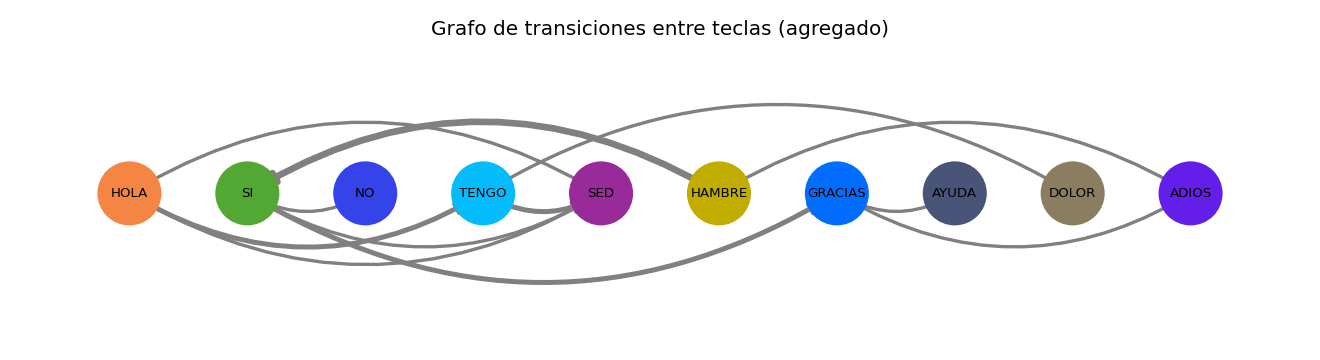

In [5]:
G = graph_analysis.unir_grafos(grafos_sesion)
print(f"Grafo agregado: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")

ruta_grafo = visualization.plot_grafo_agregado(G)
from IPython.display import Image
Image(ruta_grafo)


### 4.1 Métricas topológicas

In [6]:
display(graph_analysis.calcular_metricas(G))


,n_nodos,n_aristas,densidad,grado_medio,componentes_conexas (no dirigido),diametro_componente_mayor,coef_agrupamiento_medio
0,10,12,0.133,2.4,1,5,0.167


### 4.2 Centralidad y relevancia

,grado,intermediacion,cercania,pagerank
SED,0.444,0.139,0.389,0.254
HOLA,0.333,0.069,0.272,0.238
TENGO,0.333,0.028,0.247,0.175
SI,0.444,0.236,0.167,0.073
HAMBRE,0.222,0.167,0.167,0.060
GRACIAS,0.333,0.083,0.167,0.053
ADIOS,0.222,0.097,0.167,0.044
AYUDA,0.111,0.000,0.178,0.044
NO,0.111,0.000,0.178,0.037
DOLOR,0.111,0.000,0.000,0.022


Tecla más relevante según PageRank: SED


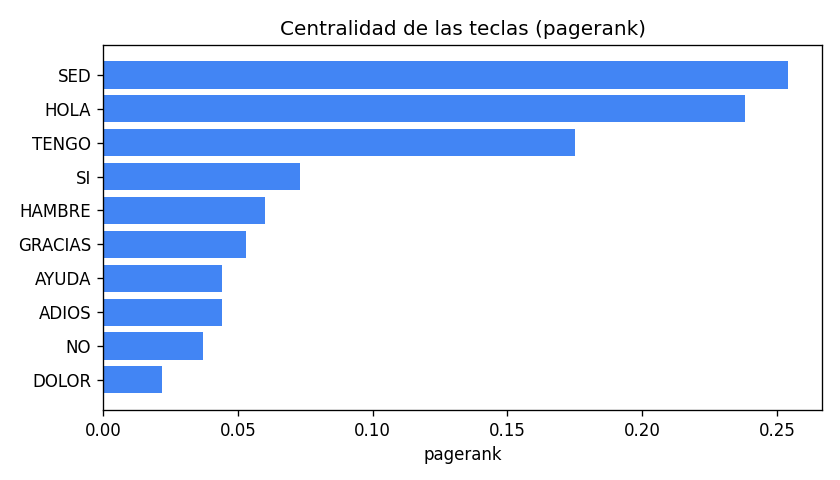

In [7]:
centralidades = graph_analysis.calcular_centralidades(G)
display(centralidades)
print("Tecla más relevante según PageRank:",
      centralidades["pagerank"].idxmax() if G.number_of_edges() > 0 else "N/A (sin aristas aún)")

ruta_centralidades = visualization.plot_centralidades(centralidades)
Image(ruta_centralidades)


### 4.3 Resiliencia estructural

In [8]:
resiliencia = graph_analysis.analizar_resiliencia(G, centralidades)
if resiliencia:
    print(f"Nodo removido (mayor PageRank): {resiliencia['nodo_removido']}")
    print(f"Tamaño de la componente mayor  ANTES: {resiliencia['tam_cc_antes']}")
    print(f"Tamaño de la componente mayor DESPUÉS: {resiliencia['tam_cc_despues']}")
    print(f"N° de componentes ANTES: {resiliencia['n_componentes_antes']} | "
          f"DESPUÉS: {resiliencia['n_componentes_despues']}")
else:
    print("Sin aristas suficientes para evaluar resiliencia.")


Nodo removido (mayor PageRank): SED
Tamaño de la componente mayor  ANTES: 10
Tamaño de la componente mayor DESPUÉS: 6
N° de componentes ANTES: 1 | DESPUÉS: 2


### 4.4 Evolución del grafo

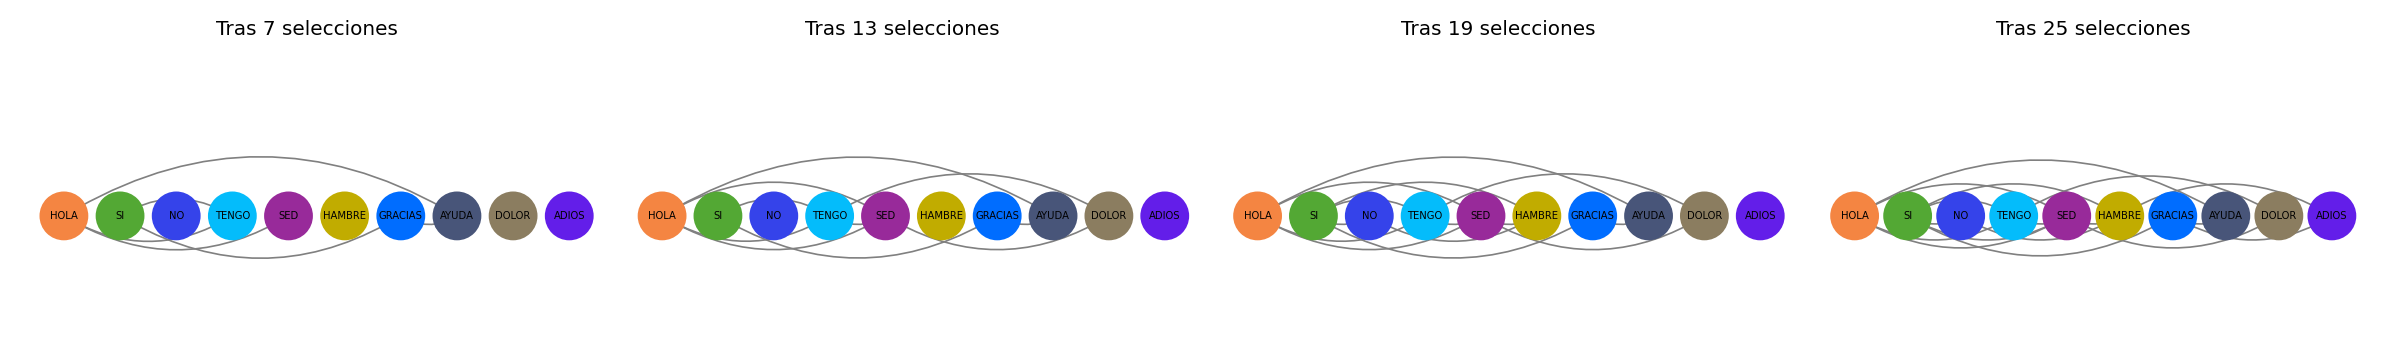

In [9]:
snapshots = graph_analysis.reconstruir_evolucion(resultado["log_selecciones"])
ruta_evolucion = visualization.plot_evolucion(snapshots)
Image(ruta_evolucion) if ruta_evolucion else print("No hay selecciones suficientes.")


### 4.5 Detección de comunidades

In [10]:
comunidades = graph_analysis.detectar_comunidades(G)
if comunidades:
    for i, com in enumerate(comunidades["comunidades"], 1):
        print(f"Comunidad {i}: {com}")
    print(f"\nModularidad: {comunidades['modularidad']}")
else:
    print("Se necesitan aristas para detectar comunidades.")


Comunidad 1: ['ADIOS', 'AYUDA', 'GRACIAS', 'HAMBRE', 'NO', 'SI']
Comunidad 2: ['DOLOR', 'HOLA', 'SED', 'TENGO']

Modularidad: 0.42


### 4.6 Proceso de difusión (cascada independiente)

In [11]:
if G.number_of_edges() > 0 and mensajes:
    semilla = mensajes[0][0]
    historial = graph_analysis.cascada_independiente(G, semilla)
    for paso, activos in enumerate(historial):
        print(f"Paso {paso}: {sorted(activos)}")
else:
    print("Se necesita al menos un mensaje con aristas para simular la difusión.")


Paso 0: ['HOLA']
Paso 1: ['HOLA', 'SED', 'TENGO']
Paso 2: ['HOLA', 'SED', 'TENGO']


## 5) Discusión final

**Sobre la postura como interfaz de control**: usar la postura "L" (en vez
de un gesto de mano) para los comandos de inicio/fin evita interferir con
la mano que se usa simultáneamente para seleccionar teclas, separando el
canal de "control de sesión" (cuerpo) del canal de "selección" (dedo
índice).

**Sobre el grafo como modelo de comunicación**: representar el teclado
como grafo permite ir más allá de "qué palabras se usaron" para preguntar
"en qué orden y con qué fuerza se conectan las ideas": la centralidad
señala palabras-eje del vocabulario del usuario, la resiliencia indica
qué tan dependiente es su patrón comunicativo de una sola tecla (relevante
en un sistema de asistencia real, donde perder esa tecla por un fallo de
hardware sería crítico), y las comunidades sugieren agrupaciones temáticas
de palabras que convendría ubicar físicamente cerca en el teclado.

**Sobre el autocompletado**: el mismo grafo dirigido y ponderado que se
analiza arriba es, en tiempo real, el motor de sugerencias —
`sugerir_siguientes()` solo lee los sucesores de mayor peso del nodo
activo. Es el mismo principio que la cascada independiente (activar
vecinos con probabilidad proporcional al peso), aplicado a un único paso
hacia adelante y con fines predictivos. Es, en esencia, un modelo de
lenguaje bigrama sobre un vocabulario cerrado de 10 palabras: funciona con
pocos datos porque el vocabulario es pequeño, y mejora con el uso porque
cada selección real refuerza el peso de la arista correspondiente
(aprendizaje incremental simple, sin reentrenar nada).

**Limitación reconocida**: los datos usados aquí son simulados (o, en su
defecto, provienen de una única grabación de prueba) y dependen
fuertemente de la secuencia elegida; las métricas (densidad, modularidad,
centralidad) cobran sentido estadístico real recién con múltiples
sesiones de uso reales del sistema.